In [1]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from panel_segmentation import utils
import glob
import matplotlib.pyplot as plt
from PIL import Image
import os
from shapely.geometry import Polygon
import geopandas
from mmengine import Config
from mmdet.apis import init_detector, inference_detector
from mmdet.registry import VISUALIZERS
from shapely.geometry import Polygon
import mmcv
import numpy as np
import pandas as pd
import torch

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\mmengine\optim\optimizer\zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \


# Panel Detection

The following example uses the panel detection pipeline to detect solar panels in satellite imagery and get their mounting configuration and azimuth. Let's use an NREL site as an example and get its latitude-longitude coordinates.

In [2]:
#Example latitude-longitude coordinates to run the analysis on.
latitude = 39.7407
longitude = -105.1694    
google_maps_api_key = "YOUR API KEY HERE"
file_name = "../../../panel_segmentation/examples/Panel_Detection_Examples/sat_img_ex.png"

Load in the image and declare it as a numpy array.

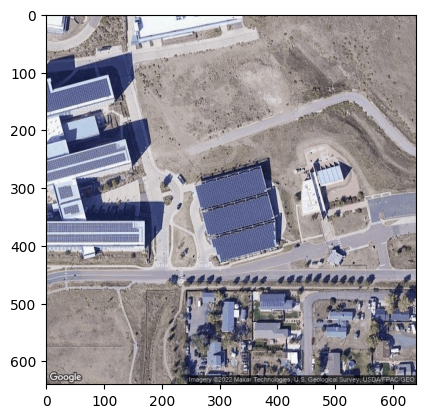

In [3]:
x = Image.open(file_name)
plt.imshow(x)
plt.show()

Read in the Panel-detection model for testing.

In [4]:
# Get hail model and checkpoint
cfg = Config.fromfile("../../../panel_segmentation/models/hail_config.py")
checkpoint_file = "../../../panel_segmentation/models/hail_model.pth"
model = init_detector(cfg, device='cpu')
checkpoint = torch.load(checkpoint_file, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['state_dict'])
visualizer = VISUALIZERS.build(model.cfg.visualizer)

c:\users\kperry\documents\source\repos\mmdetection\mmdet\apis\inference.py:70: UserWarning: checkpoint is None, use COCO classes by default.
  warnings.warn('checkpoint is None, use COCO classes by default.')


Run the image through model. 

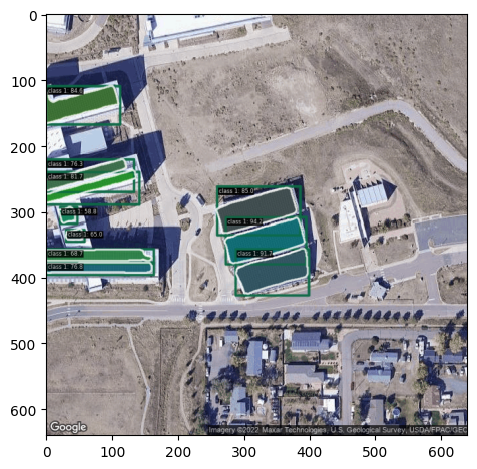

In [7]:
img = mmcv.imread(file_name, channel_order='rgb')
result = inference_detector(model, img)
visualizer.add_datasample(
          file_name,
          img,
          data_sample=result,
          draw_gt=None,
          wait_time=0,
          pred_score_thr=0.35
          )
img = visualizer.get_image()
plt.imshow(img)
plt.tight_layout()
plt.show()

Calculate the individual azimuth for each installation.

164
163
163
164
164
179
164
180
179
255


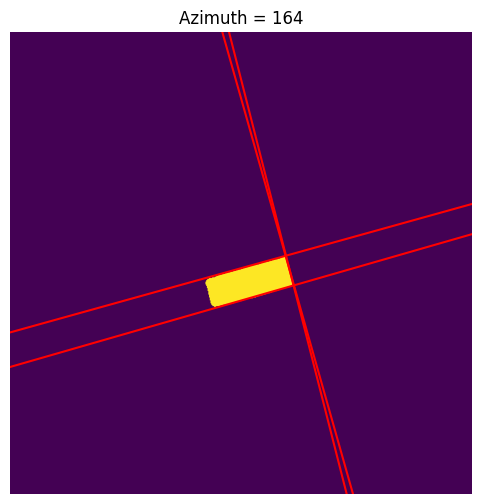

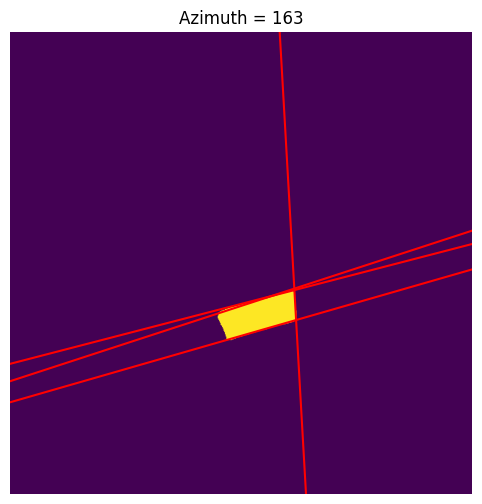

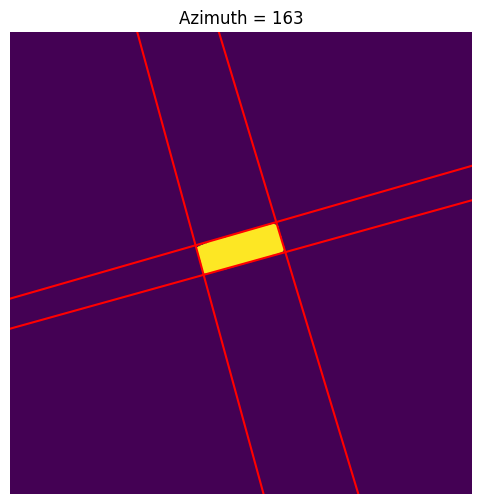

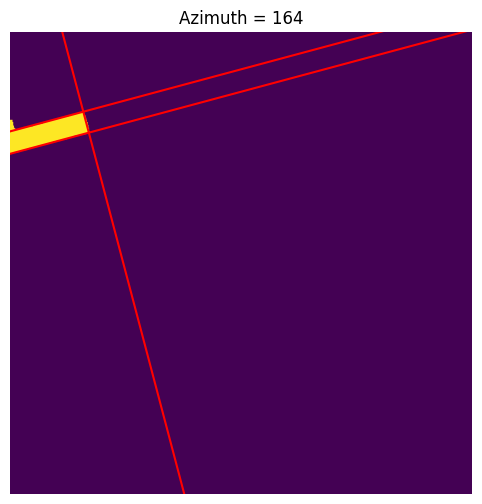

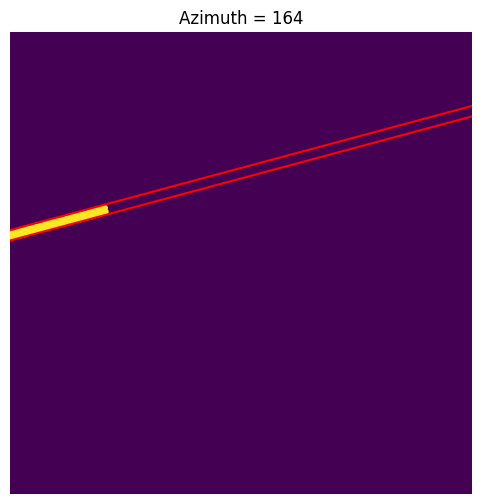

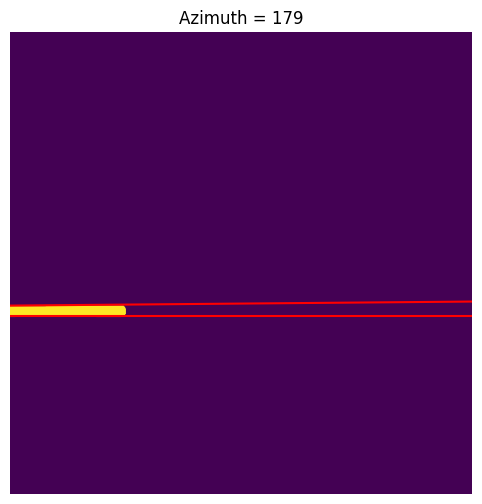

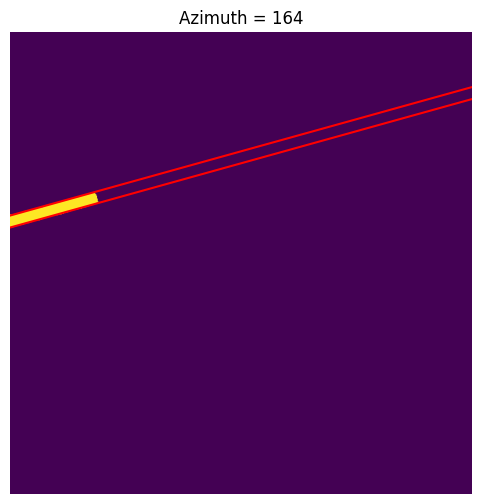

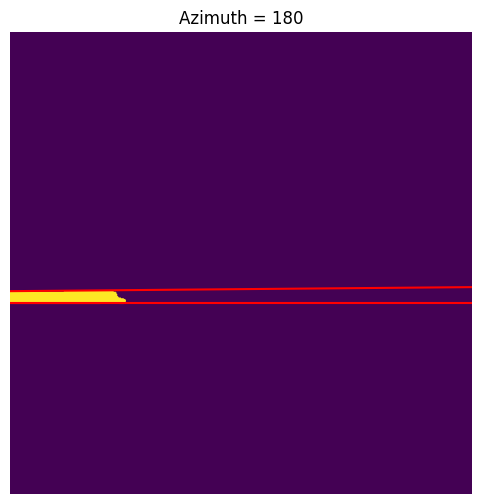

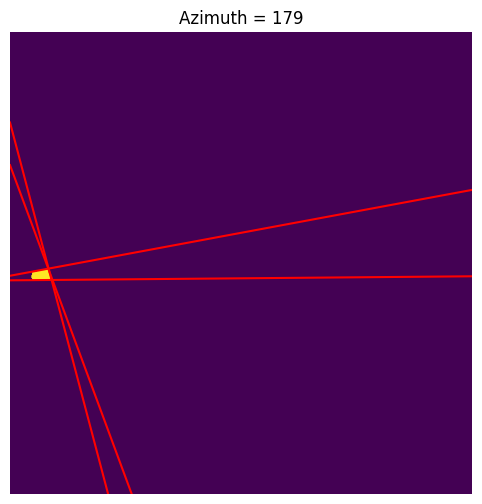

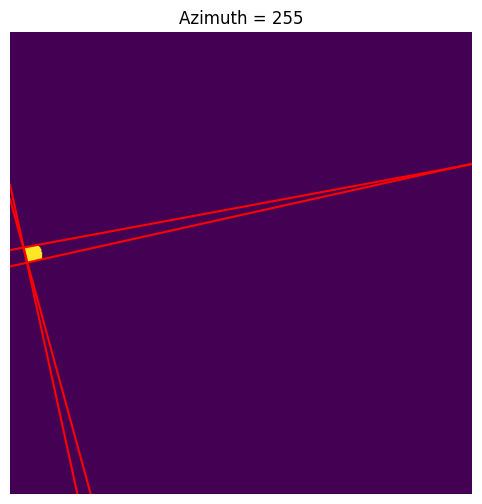

In [8]:
predictions = result._pred_instances
masks  = predictions.masks
labels = predictions.labels
scores = predictions.scores

idx_to_keep = np.argwhere(scores >= 0.35).tolist()[0]
image_x_pixels, image_y_pixels = result.img_shape
n_kept = 0

for index in range(len(masks)):
    if index in idx_to_keep:
        segmentation_mask = masks[index].data.cpu().numpy()
        # Apply the azimuth estimator to the mask
        azimuth = utils.detectAzimuth(segmentation_mask)
        print(azimuth)
        utils.plotEdgeAz(segmentation_mask)